# Intel Image Classification using CNNs

In [1]:
!mkdir -p ~/.kaggle  #create folder for dataset
!cp kaggle.json ~/.kaggle/   #Take permission

## 1. Setup and Data Extraction
This section handles downloading the dataset from Kaggle and extracting its contents, preparing the image files for use.

In [2]:
!kaggle datasets download -d puneet6060/intel-image-classification

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
intel-image-classification.zip: Skipping, found more recently modified local copy (use --force to force download)


In [3]:
# unzip files
import zipfile
unzip = zipfile.ZipFile('/content/intel-image-classification.zip')
unzip.extractall()
unzip.close()

## 2. Import Libraries
Essential libraries for building and training the CNN model are imported here, including TensorFlow, Keras, OpenCV, and Matplotlib.

In [4]:
# Libraries in python
from tensorflow import keras
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten

## 3. Load and Preprocess Data
Images are loaded using `image_dataset_from_directory`, and then normalized to a 0-1 range. This step ensures the data is in the correct format and scale for model training.

In [5]:
# Generators(Creating batches as the dataset is large)
train= keras.utils.image_dataset_from_directory(
    directory= '/content/seg_train/seg_train',
    labels= 'inferred',
    label_mode= 'int',
    batch_size= 32,
    image_size=(168,168)
)

test= keras.utils.image_dataset_from_directory(
    directory= '/content/seg_test/seg_test',
    labels= 'inferred',
    label_mode= 'int',
    batch_size= 32,
    image_size=(168,168))

Found 14034 files belonging to 6 classes.
Found 3000 files belonging to 6 classes.


In [6]:
print(train.class_names)

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [7]:
for images,labels in train.take(2):
  print(images.shape)
  print(labels.shape)

(32, 168, 168, 3)
(32,)
(32, 168, 168, 3)
(32,)


In [8]:
# Data Normalization
train_norm= train.map(lambda image, label: (image/255, label))
test_norm= test.map(lambda image, label: (image/255, label))

## 4. CNN Model Architecture
This section defines the Convolutional Neural Network (CNN) model using Keras Sequential API, including `Conv2D`, `MaxPool2D`, `Flatten`, and `Dense` layers.

In [9]:
# Model building

In [10]:
from tensorflow.keras.layers import Input

model = Sequential()

model.add(Input(shape=(168,168,3)))
model.add(Conv2D(32, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(MaxPool2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(64, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(MaxPool2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(128, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(MaxPool2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(256, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(MaxPool2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(6, activation='softmax'))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

## 5. Compile and Train Model
The model is compiled with an Adam optimizer and `sparse_categorical_crossentropy` loss. Training is then initiated on the prepared dataset.

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 166, 166, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 83, 83, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 81, 81, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 38, 38, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 19, 19, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 17, 17, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,494,342 (9.52 MB)

 Trainable params: 2,494,342 (9.52 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.fit(train_norm, epochs=18)

Epoch 1/18
439/439 ━━━━━━━━━━━━━━━━━━━━ 26s 44ms/step - accuracy: 0.5849 - loss: 1.0372
Epoch 2/18
439/439 ━━━━━━━━━━━━━━━━━━━━ 15s 34ms/step - accuracy: 0.7295 - loss: 0.7299
Epoch 3/18
439/439 ━━━━━━━━━━━━━━━━━━━━ 15s 34ms/step - accuracy: 0.7907 - loss: 0.5705
Epoch 4/18
439/439 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.8299 - loss: 0.4756
Epoch 5/18
439/439 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.8580 - loss: 0.3953
Epoch 6/18
439/439 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.8904 - loss: 0.3096
Epoch 7/18
439/439 ━━━━━━━━━━━━━━━━━━━━ 15s 34ms/step - accuracy: 0.9053 - loss: 0.2696
Epoch 8/18
439/439 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.9227 - loss: 0.2181
Epoch 9/18
439/439 ━━━━━━━━━━━━━━━━━━━━ 15s 34ms/step - accuracy: 0.9463 - loss: 0.1595
Epoch 10/18
439/439 ━━━━━━━━━━━━━━━━━━━━ 15s 34ms/step - accuracy: 0.9561 - loss: 0.1307
Epoch 11/18
439/439 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.9582 - loss: 0.1255
Epoch 12/18
439/439 ━━━━━━━━━━

## 6. Model Prediction
After training, the model generates predictions on the test dataset. The raw output probabilities are converted into predicted class indices.

In [13]:
prediction = model.predict(test_norm)

94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step


In [14]:
prediction

array([[5.10066775e-06, 2.25959182e-10, 8.91456425e-01, 1.08538359e-01,
        1.02298159e-09, 7.92620938e-08],
       [2.35554493e-10, 1.00000000e+00, 5.67166616e-08, 9.33724886e-13,
        8.02917541e-12, 4.71897910e-10],
       [3.39363130e-12, 7.63465541e-11, 2.22269496e-13, 9.66694963e-19,
        3.46822603e-18, 1.00000000e+00],
       ...,
       [8.36430125e-09, 4.14682017e-06, 2.42132437e-03, 9.97559428e-01,
        1.50530668e-05, 6.95548966e-11],
       [1.00000000e+00, 3.29020038e-15, 1.68135908e-10, 2.45923074e-12,
        3.07570254e-11, 1.55242180e-10],
       [3.96694304e-08, 1.05861865e-03, 1.06581865e-04, 9.98737752e-01,
        9.70469337e-05, 7.26126625e-09]], dtype=float32)

In [15]:
import numpy as np

predicted_class = np.argmax(prediction, axis=1)

print(predicted_class)

[2 1 5 ... 3 0 3]


## 7. Map Predictions to Class Names
Predicted numerical labels are mapped to their corresponding human-readable class names (e.g., 'buildings', 'forest').

In [16]:
class_names = [
    "buildings",
    "forest",
    "glacier",
    "mountain",
    "sea",
    "street"
]

predicted_labels = [class_names[i] for i in predicted_class]

print(predicted_labels[:10])

['glacier', 'forest', 'street', 'mountain', 'street', 'sea', 'sea', 'buildings', 'mountain', 'street']


## 8. Custom Image Prediction Demo
This section demonstrates how to use the trained model to predict the class of individual, unseen images. Each image is loaded, preprocessed, and then passed to the model for classification.

In [17]:
import cv2
import matplotlib.pyplot as plt

### Image 1 & Prediction

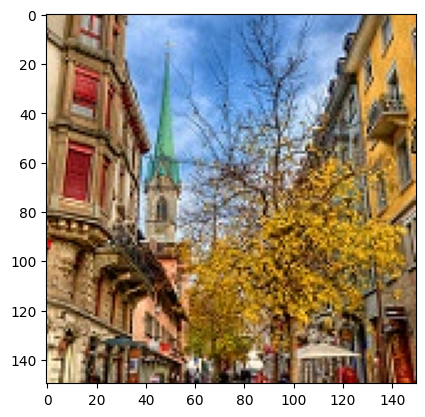

In [18]:
a = cv2.imread("/content/seg_pred/seg_pred/10004.jpg")
a = cv2.cvtColor(a, cv2.COLOR_BGR2RGB)

plt.imshow(a)
plt.show()

In [19]:
a.shape

(150, 150, 3)

In [20]:
test1 = cv2.resize(a, (168,168))
test1 = test1.astype("float32") / 255.0
test1 = test1.reshape(1,168,168,3)

pred = model.predict(test1)
print(pred)
print(train.class_names[np.argmax(pred)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 688ms/step
[[4.5122616e-03 8.9546019e-04 1.6146060e-04 2.1755302e-04 1.7736174e-04
  9.9403584e-01]]
street


### Image 2 & Prediction

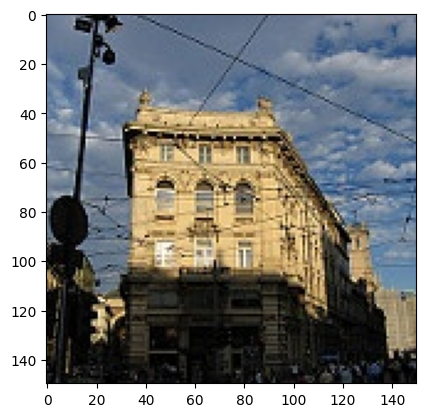

In [21]:
b = cv2.imread("/content/seg_pred/seg_pred/10048.jpg")
b = cv2.cvtColor(b, cv2.COLOR_BGR2RGB)

plt.imshow(b)
plt.show()

In [22]:
test2 = cv2.resize(b, (168,168))
test2 = test2.astype("float32") / 255.0
test2 = test2.reshape(1,168,168,3)

pred = model.predict(test2)
print(pred)
print(train.class_names[np.argmax(pred)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
[[9.9933738e-01 2.9654569e-08 6.7834651e-07 6.9238101e-11 1.0883530e-05
  6.5109559e-04]]
buildings


### Image 3 & prediction

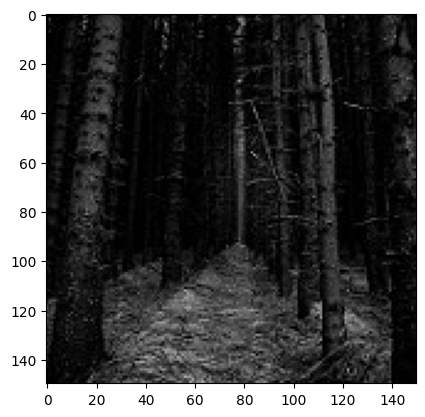

In [23]:
c = cv2.imread("/content/seg_pred/seg_pred/1168.jpg")
c = cv2.cvtColor(c, cv2.COLOR_BGR2RGB)

plt.imshow(c)
plt.show()

In [24]:
test3 = cv2.resize(c, (168,168))
test3 = test3.astype("float32") / 255.0
test3 = test3.reshape(1,168,168,3)

pred = model.predict(test3)
print(pred)
print(train.class_names[np.argmax(pred)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
[[3.3400283e-08 9.9998772e-01 1.1019198e-05 1.4654172e-08 2.3964250e-07
  1.0920904e-06]]
forest


## 9. Batch Prediction on `seg_pred` Directory
This section contains the code to iterate through all images in the `/content/seg_pred/seg_pred` directory, preprocess each image, and then use the trained model to predict its class label. The predictions are printed for each image.

In [25]:
import os

image_dir = "/content/seg_pred/seg_pred"
image_files = [os.path.join(image_dir, f) for f in os.listdir(image_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]

print(f"Found {len(image_files)} images in {image_dir}.")

for img_path in image_files:
    try:
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Preprocess the image
        resized_img = cv2.resize(img, (168, 168))
        normalized_img = resized_img.astype("float32") / 255.0
        reshaped_img = normalized_img.reshape(1, 168, 168, 3)

        # Make prediction
        pred = model.predict(reshaped_img, verbose=0)
        predicted_class_index = np.argmax(pred)
        predicted_class_name = train.class_names[predicted_class_index]

        print(f"Image: {os.path.basename(img_path)} -> Predicted Class: {predicted_class_name}")

    except Exception as e:
        print(f"Error processing {os.path.basename(img_path)}: {e}")

Streaming output truncated to the last 5000 lines.
Image: 12778.jpg -> Predicted Class: sea
Image: 3289.jpg -> Predicted Class: mountain
Image: 18924.jpg -> Predicted Class: sea
Image: 5151.jpg -> Predicted Class: mountain
Image: 12207.jpg -> Predicted Class: forest
Image: 5959.jpg -> Predicted Class: glacier
Image: 20462.jpg -> Predicted Class: street
Image: 18729.jpg -> Predicted Class: mountain
Image: 11227.jpg -> Predicted Class: buildings
Image: 13433.jpg -> Predicted Class: mountain
Image: 24331.jpg -> Predicted Class: forest
Image: 11997.jpg -> Predicted Class: glacier
Image: 11538.jpg -> Predicted Class: mountain
Image: 3854.jpg -> Predicted Class: sea
Image: 2813.jpg -> Predicted Class: sea
Image: 5509.jpg -> Predicted Class: mountain
Image: 21124.jpg -> Predicted Class: buildings
Image: 4545.jpg -> Predicted Class: sea
Image: 985.jpg -> Predicted Class: glacier
Image: 23768.jpg -> Predicted Class: forest
Image: 11849.jpg -> Predicted Class: buildings
Image: 1598.jpg -> Predic

## 10. Model Evaluation on Test Set
This section evaluates the model's performance on the dedicated test set using various metrics like accuracy, precision, recall, and a confusion matrix to understand its strengths and weaknesses.

Overall Accuracy on Test Set: 0.1770

Classification Report:
              precision    recall  f1-score   support

   buildings       0.14      0.14      0.14       437
      forest       0.15      0.16      0.15       474
     glacier       0.20      0.24      0.22       553
    mountain       0.20      0.18      0.19       525
         sea       0.18      0.15      0.16       510
      street       0.18      0.18      0.18       501

    accuracy                           0.18      3000
   macro avg       0.17      0.17      0.17      3000
weighted avg       0.18      0.18      0.18      3000



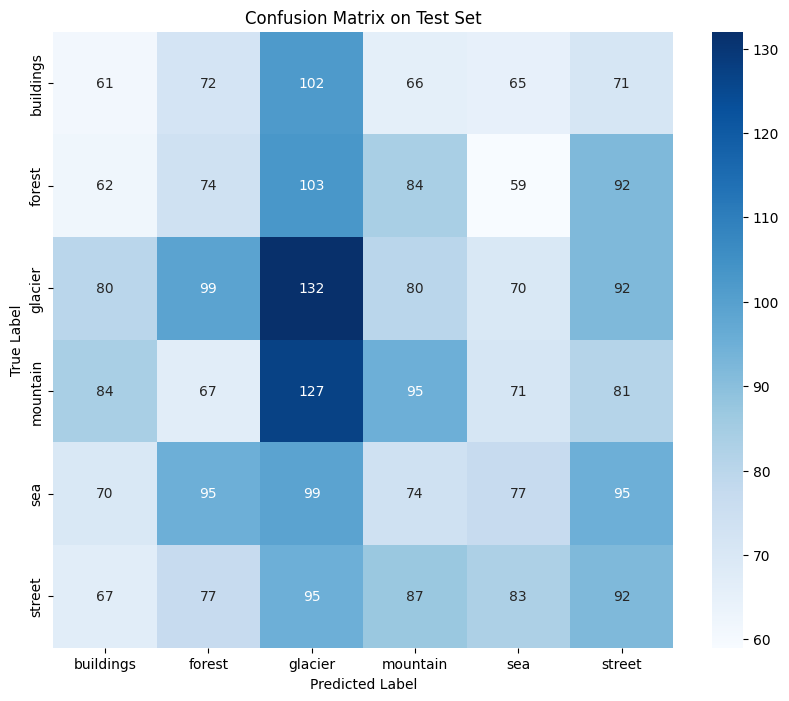

In [26]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Extract true labels from the test dataset
true_labels = []
for _, labels in test:
    true_labels.extend(labels.numpy())
true_labels = np.array(true_labels)

# Calculate overall accuracy
accuracy = accuracy_score(true_labels, predicted_class)
print(f"Overall Accuracy on Test Set: {accuracy:.4f}")

# Generate classification report
print("\nClassification Report:")
print(classification_report(true_labels, predicted_class, target_names=train.class_names))

# Generate Confusion Matrix
cm = confusion_matrix(true_labels, predicted_class)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=train.class_names, yticklabels=train.class_names)
plt.title('Confusion Matrix on Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()